In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
spam = pd.read_csv('/content/spam.csv')

In [ ]:
spam.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
spam.tail()

,Category,Message
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [ ]:
spam.shape

(5572, 2)

In [ ]:
spam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
spam.ndim

2

In [ ]:
spam['Category'] = spam['Category'].apply(lambda x:1 if x== 'spam' else 0)

In [ ]:
spam['Category']

,Category
0,0
1,0
2,1
3,0
4,0
...,...
5567,1
5568,0
5569,0
5570,0


In [ ]:
spam['Category'].value_counts()

,count
Category,
0,4825
1,747


([<matplotlib.patches.Wedge at 0x7d7e53f86900>,
  ...],
 [Text(1.1, 0.0, ''),
  Text(1.1, 0.0, ''),
  Text(1.0999902720652674, 0.004626160587223182, ''),
  Text(1.0999610884331297, 0.009252239350831358, ''),
  Text(1.0999610884331297, 0.009252239350831358, ''),
  Text(1.099912449639149, 0.0138781529320968, ''),
  Text(1.0998443564854454, 0.018503824121425982, ''),
  Text(1.0998443564854454, 0.018503824121425982, ''),
  Text(1.0997568102453255, 0.023129165982093133, ''),
  Text(1.0995233649057938, 0.032378542682474795, ''),
  Text(1.0993774699870607, 0.0370024118788175, ''),
  Text(1.0992121302914866, 0.04162562456050352, ''),
  Text(1.0988231282407952, 0.05086976354489059, ''),
  Text(1.098599472938297, 0.05549052225106639, ''),
  Text(1.098599472938297, 0.05549052225106639, ''),
  Text(1.0983563865591865, 0.060110299488913034, ''),
  Text(1.098093873161831, 0.06472901763852773, ''),
  Text(1.098093873161831, 0.06472901763852773, ''),
  Text(1.098093873161831, 0.06472901763852773, ''),

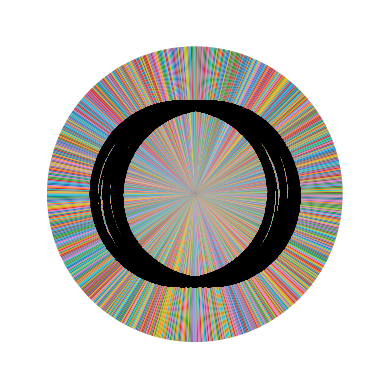

In [ ]:
plt.pie(spam['Category'],autopct='%1.1f%%')

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(min_df=5, max_features=7000,ngram_range=(1,3))

In [ ]:
train_ex = {'the sun in the sky is very bright', 'its the sunny day'}

In [ ]:
vectorizer.fit_transform(train_ex)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 11 stored elements and shape (2, 10)>

In [ ]:
vectorizer.vocabulary_

{'its': 4,
 'the': 8,
 'sunny': 7,
 'day': 1,
 'sun': 6,
 'in': 2,
 'sky': 5,
 'is': 3,
 'very': 9,
 'bright': 0}

In [ ]:
train_vec = vectorizer.fit_transform(train_ex)

In [ ]:
train_vec.toarray()

array([[0, 1, 0, 0, 1, 0, 0, 1, 1, 0],
       [1, 0, 1, 1, 0, 1, 1, 0, 2, 1]])

In [ ]:
vectorizer.inverse_transform(train_vec)

[array(['0089', '0125698789', '01223585334', '000'], dtype='<U34'),
 array(['0125698789', '01223585236', '000pes', '0121', '008704050406',
        '02', '00'], dtype='<U34')]

In [ ]:
X_vec = vectorizer.fit_transform(spam['Message'])

In [ ]:
spam['Message'].shape

(5572,)

In [ ]:
X_vec.shape

(5572, 4722)

In [ ]:
X_vec=X_vec.toarray()

In [ ]:
y = spam['Category']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_vec,y, test_size=0.2, random_state = 42)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB

In [ ]:
%%time
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
knn_model.score(X_train, y_train)

CPU times: user 7.11 s, sys: 182 ms, total: 7.29 s
Wall time: 5.84 s


0.9360556428090644

In [ ]:
%%time
svc_model = SVC()
svc_model.fit(X_train, y_train)
svc_model.score(X_train, y_train)

CPU times: user 1min 3s, sys: 219 ms, total: 1min 4s
Wall time: 1min 4s


0.9943908458604442

In [ ]:
%%time
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_model.score(X_train, y_train)

CPU times: user 272 ms, sys: 26.9 ms, total: 298 ms
Wall time: 260 ms


0.988332959389724